# Deliverable 2 — Comparative Analysis of Numerical Interpolation Methods for Robot Trajectory Planning

**Author:** Param Chokshi
**Course:** CISC 601 Scientific Computing 2
**Textbook:** Chapra & Canale, *Numerical Methods for Engineers* (8th ed.), Chapters 18, 24, 28

This notebook is the executable companion to the Deliverable 2 submission. It loads the synthetic robotics datasets, runs each of the four interpolation methods through the project's Python implementation, sweeps over waypoint density / geometry / time-spacing as called for in the Deliverable 1 methodology, validates the analytic derivatives against numerical differentiation, and surfaces the boundary-condition sensitivity of the quintic spline.

The implementations live in the sibling `src/` package and follow the textbook formulations: Eq 18.2 for linear, Eq 18.36 / Eq 18.37 for cubic, the quintic Hermite system for C⁴ quintic splines, and the Cox–de Boor recursion for B-splines. See `deliverable2_methodology.md` for the full derivations and references.

## Background and motivation

Robots move by following sequences of waypoints — positions a higher-level planner has decided the robot should pass through. A waypoint sequence on its own is just a list of points; turning it into a trajectory the robot can actually execute requires *interpolating* between those points to fill in the motion in time. The way that interpolation is done has direct mechanical consequences:

* If the trajectory has a **velocity discontinuity** at any waypoint, the robot would need infinite acceleration to follow it exactly.
* If the **acceleration profile is rough**, the robot's motors must apply correspondingly rough torques, wearing the drivetrain and shaking the payload.
* If the **jerk** (the derivative of acceleration) is large, the robot vibrates audibly and any unsecured payload will slosh or shift.

The four interpolation methods we compare differ in exactly which of these continuity properties they guarantee:

| Method | Passes through waypoints? | Continuity guaranteed |
|---|---|---|
| Linear (Eq 18.2) | Yes | Position only (C⁰) |
| Cubic spline (Eq 18.36) | Yes | Position, velocity, acceleration (C²) |
| Quintic spline (C⁴ Hermite) | Yes | Position, velocity, acceleration, jerk, snap (C⁴) |
| Cubic B-spline (Cox–de Boor) | First and last only | C² across the whole curve |

In principle "more continuity" is always better; in practice, every additional constraint has to be paid for somewhere, and the experiment in this notebook quantifies how that trade-off plays out on realistic robotics scenarios.

### What this notebook contains

* **§1–§3** introduce the two baseline scenarios — a mobile robot navigating a warehouse aisle, and a 2-DOF planar arm executing a pick-and-place — and run all four methods on them. These sections answer "what do the methods look like?".
* **§4** runs the full experimental sweep called for in the Deliverable 1 proposal: varying waypoint density (5 / 12 / 20), geometric character (sharp vs gradual), and time spacing (chord-length vs uniform). These answer "how do the methods scale?".
* **§5** validates that our analytic derivative formulas are correct by comparing them against centered finite differences (Chapra Ch 28).
* **§6** investigates a surprise from the baseline run: that the quintic spline appeared to produce *higher* jerk than the cubic. We show this is a boundary-condition artefact, not a property of the method.
* **§7** summarises the eight findings that fall out of the data.

Every figure and table in this notebook is generated from the same `src/` package — there are no precomputed artefacts.

## 1. Setup

In [1]:
# Locate the deliverable2 directory robustly so this notebook works
# whether Jupyter is launched from inside deliverable2/, from a parent
# directory, or via VS Code's notebook UI (where Path.cwd() can be the
# user's home directory).
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    marker = Path("src") / "datasets" / "path_generators.py"
    candidates = [start, *start.parents, Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / marker).is_file():
            return candidate
    raise RuntimeError(
        "Could not find the deliverable2 project root. Open this notebook "
        "from inside the deliverable2 directory or set the working directory "
        "before running this cell."
    )


# Try the notebook's own file location first (set by VS Code / nbclient),
# fall back to the working directory.
_seed = Path(globals().get("__vsc_ipynb_file__", Path.cwd())).resolve()
PROJECT_ROOT = _find_project_root(_seed)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

from src.datasets import (
    generate_mobile_robot_waypoints,
    generate_robot_arm_waypoints,
    forward_kinematics,
    all_variants,
    make_mixed_variant,
    make_sharp_variant,
    make_gradual_variant,
)
from src.datasets.variants import WaypointDataset
from src.experiment import (
    METHOD_KEYS,
    evaluate_all_methods,
    run_experiment,
    analytic_vs_empirical_derivative,
    quintic_bc_sensitivity,
)
from src.plots import METHOD_COLOURS, METHOD_LABELS

N_DENSE = 1000


def magnitude(arr):
    if arr.ndim == 1:
        return np.abs(arr)
    return np.linalg.norm(arr, axis=-1)


print("numpy", np.__version__, "/ pandas", pd.__version__)

numpy 2.4.6 / pandas 3.0.3


## 2. Mobile robot baseline dataset

We start with a 2-D scenario chosen to exercise every method on a path that mixes the cases they typically struggle with and the cases they handle gracefully. The waypoints (read from the polyline below) describe a robot following a warehouse aisle:

* a straight entry segment from the loading dock to the first turn,
* a sharp 90° right turn around a shelving unit,
* a diagonal traverse to a pick station,
* a 90° left turn back into the aisle, and
* a gentle S-curve toward the exit.

The two sharp turns are the stress test: a hard corner is geometrically a place where the path's tangent direction changes discontinuously, which forces every smooth interpolant to make a choice about how to round it off. The S-curve is the easy case: a smooth path that every method should follow with little drama.

Waypoint timing uses **chord-length parameterisation** at a nominal speed of 1 m/s. Concretely, the time between two consecutive waypoints is set proportional to the Euclidean distance between them (Δt = chord / v_nom), which makes the implied speed uniform and is the recommendation in §24.1 of Chapra and Canale for irregularly spaced data. Without this step, the methods would have to fight inconsistent implied speeds along with the geometry.

In [2]:
mobile = generate_mobile_robot_waypoints()
mobile_df = mobile.to_dataframe()
print(f"{mobile.name}: {len(mobile.t)} waypoints, T_total = {mobile.t[-1]:.2f}s")
mobile_df

mobile_robot: 12 waypoints, T_total = 24.93s


,t_s,x_m,y_m
0,0.000000,0.0,0.0
1,2.000000,2.0,0.0
2,4.000000,4.0,0.0
3,6.000000,4.0,-2.0
4,8.000000,4.0,-4.0
5,10.915476,6.5,-5.5
6,13.830952,9.0,-4.0
7,16.830952,9.0,-1.0
8,19.067020,8.0,1.0
9,20.869796,7.0,2.5


The polygon below shows what *linear* interpolation would produce — straight-line segments connecting consecutive waypoints. This is also the geometric reference against which the smooth methods will be compared in the next subsection.

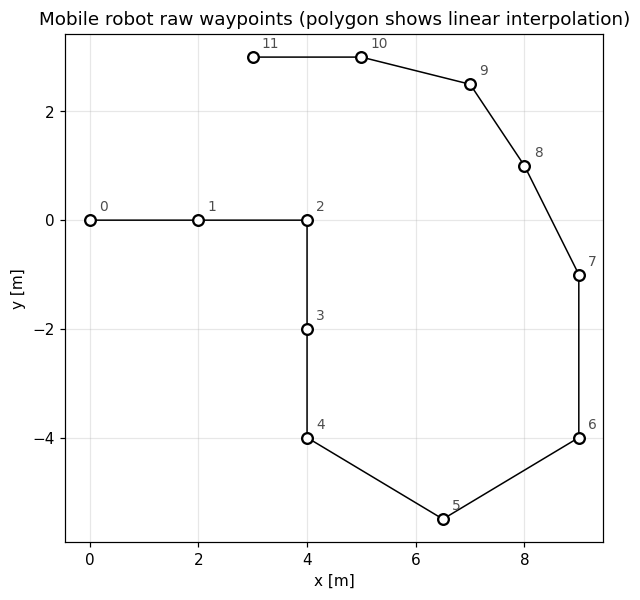

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mobile.p[:, 0], mobile.p[:, 1], "ko-", lw=1.0, ms=7,
        markerfacecolor="white", markeredgewidth=1.5)
for i, (x, y) in enumerate(mobile.p):
    ax.annotate(str(i), (x, y), xytext=(6, 6), textcoords="offset points",
                fontsize=9, color="0.3")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.set_title("Mobile robot raw waypoints (polygon shows linear interpolation)")
plt.show()

### 2.1 Trajectories from the four interpolation methods

We now run all four methods on the same waypoint sequence and dense-sample each at 1000 evenly spaced times. Three of the methods are *interpolating* (they pass through every waypoint exactly): linear, cubic spline, and quintic spline. The fourth — the cubic B-spline — is *approximating*: it uses the waypoints as control points that pull the curve in their direction without forcing it to coincide with them, so it generally cuts corners.

Things to look for in the figure:

* **Linear (gray)** is identical to the waypoint polygon — that is its definition. Every "round" feature comes from a smooth method visibly bending away from a polygon segment.
* **Cubic and quintic (blue/green)** both pass through every waypoint, but they round the corners differently. Watch how each handles the two 90° corners (waypoints 2→3→4 and 6→7).
* **B-spline (red)** matches only the first and last waypoint (this is a property of the clamped knot vector we use). For the interior it produces a clearly smoother path that systematically cuts the corners.

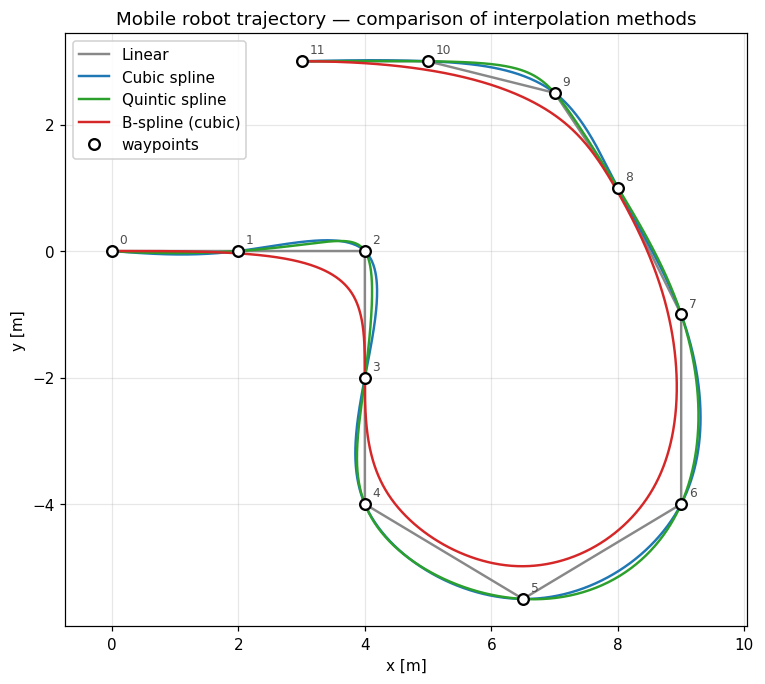

In [4]:
mobile_ds = WaypointDataset(
    name="mobile_baseline",
    description=mobile.description,
    t=mobile.t, p=mobile.p,
    units="m",
    component_names=("x", "y"),
    geometry="mixed", spacing="chord",
)
mobile_runs = evaluate_all_methods(mobile_ds, n_dense=N_DENSE)
t_query_m = np.linspace(mobile_ds.t[0], mobile_ds.t[-1], N_DENSE)

fig, ax = plt.subplots(figsize=(8, 7))
for name in METHOD_KEYS:
    r = mobile_runs[name]
    ax.plot(r.p[:, 0], r.p[:, 1], lw=1.6,
            color=METHOD_COLOURS[name], label=METHOD_LABELS[name])
ax.plot(mobile.p[:, 0], mobile.p[:, 1], "ko",
        markersize=7, markerfacecolor="white", markeredgewidth=1.5,
        label="waypoints", zorder=5)
for i, (x, y) in enumerate(mobile.p):
    ax.annotate(str(i), (x, y), xytext=(5, 5), textcoords="offset points",
                fontsize=8, color="0.3")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", framealpha=0.9)
ax.set_title("Mobile robot trajectory — comparison of interpolation methods")
plt.show()

### 2.2 Kinematic profiles (speed, |accel|, |jerk|)

Geometry is only half the story. A robot does not just need a *path* to follow; it needs a path it can follow given its actuators' bandwidth. The figure below plots the magnitude of velocity, acceleration, and jerk as functions of time for each method. These come from the **analytic derivatives** of the interpolant — every method in this project knows how to differentiate itself in closed form, so we are not relying on numerical differences here.

What each row teaches:

* **Speed (top).** Linear holds a steady 1 m/s by construction (chord-length spacing means each segment is traversed at the nominal speed). Cubic and quintic vary their speed in order to keep position smooth at the corners. The B-spline is in between.
* **|accel| (middle).** Linear shows zero analytic acceleration because each segment is a straight line traversed at constant speed. Cubic and quintic show clear "spikes" at the corners. The B-spline is the smoothest.
* **|jerk| (bottom).** This is where the textbook continuity differences become visible. Cubic spline's jerk is *piecewise constant* (the characteristic flat-step pattern), because a piecewise cubic has a constant 3rd derivative on each segment that jumps at every internal knot. Quintic spline's jerk is *continuous* — but in this configuration it spikes at the start and end, for reasons we investigate in §6.

The reading we want students to take away from this figure: **smoothness is a budget**. Each method spends it differently.

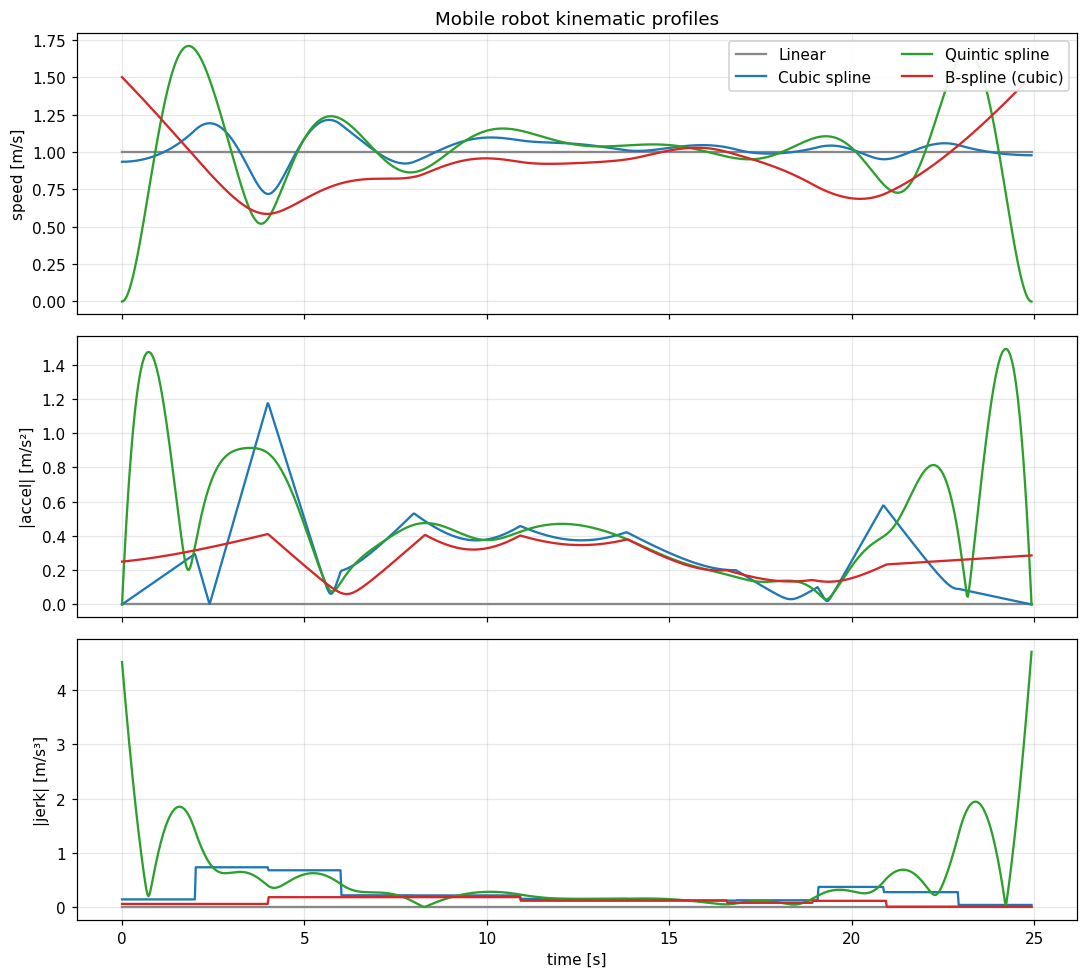

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for name in METHOD_KEYS:
    r = mobile_runs[name]
    style = dict(lw=1.5, color=METHOD_COLOURS[name], label=METHOD_LABELS[name])
    axes[0].plot(t_query_m, magnitude(r.v), **style)
    axes[1].plot(t_query_m, magnitude(r.a), **style)
    axes[2].plot(t_query_m, magnitude(r.j), **style)
axes[0].set_ylabel("speed [m/s]")
axes[1].set_ylabel("|accel| [m/s²]")
axes[2].set_ylabel("|jerk| [m/s³]")
axes[2].set_xlabel("time [s]")
axes[0].set_title("Mobile robot kinematic profiles")
for ax in axes: ax.grid(True, alpha=0.3)
axes[0].legend(loc="upper right", ncol=2, framealpha=0.9)
plt.tight_layout(); plt.show()

## 3. 2-DOF robot arm baseline dataset

The second baseline scenario is qualitatively different from the mobile robot. Where the mobile robot moves in Cartesian (x, y) directly, a robot arm is controlled in **joint space**: the controller sets joint angles, and the resulting position of the gripper is determined by the arm's geometry through *forward kinematics*.

We model a 2-DOF planar arm with link lengths $L_1 = 0.5$ m and $L_2 = 0.4$ m. The forward kinematics is

$$
x = L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2), \quad
y = L_1 \sin(\theta_1) + L_2 \sin(\theta_1 + \theta_2).
$$

The waypoints describe a complete pick-and-place cycle: home → approach the part → grasp → lift → transfer to a placement bay → pre-place hover → place → retract → home. They are specified as eight $(\theta_1, \theta_2)$ pairs in degrees (converted to radians inside the pipeline) and timed at 1 second per segment.

Why this scenario in addition to the mobile robot? Because the **interpolation happens in joint space**, but the **physical motion happens in Cartesian space**, and the relationship between the two is nonlinear (it is the cosine/sine forward kinematics above). A trajectory that looks smooth in joint angles can produce a Cartesian end-effector path that is anything but smooth — and vice versa. This is one of the more subtle issues in trajectory planning and the reason robot-arm trajectories are usually planned and benchmarked separately from mobile-robot ones.

We verify that every Cartesian waypoint lies within the arm's reachable workspace ($\|(x,y)\| \le L_1 + L_2 = 0.9$ m) before continuing.

In [6]:
arm = generate_robot_arm_waypoints()
arm_df = arm.to_dataframe()
print(f"{arm.name}: {len(arm.t)} waypoints, L1={arm.L1}m, L2={arm.L2}m, T_total = {arm.t[-1]:.2f}s")
arm_df

robot_arm: 8 waypoints, L1=0.5m, L2=0.4m, T_total = 7.00s


,t_s,theta1_deg,theta2_deg,x_m,y_m
0,0.0,0.0,0.0,0.900000,0.000000
1,1.0,30.0,-60.0,0.779423,0.050000
2,2.0,30.0,-90.0,0.633013,-0.096410
3,3.0,30.0,-60.0,0.779423,0.050000
4,4.0,75.0,-90.0,0.515780,0.379435
5,5.0,110.0,-60.0,0.086105,0.776264
6,6.0,110.0,-90.0,0.204867,0.606654
7,7.0,50.0,0.0,0.578509,0.689440


The two views below show the same waypoint set in the two coordinate systems we will care about: the joint-space view (left) is what the controller sees, and the Cartesian view (right) is what the end-effector actually traces. The dashed circle on the right marks the outer reachable workspace.

In [7]:
arm = generate_robot_arm_waypoints()
arm_df = arm.to_dataframe()
print(f"{arm.name}: {len(arm.t)} waypoints, L1={arm.L1}m, L2={arm.L2}m, T_total = {arm.t[-1]:.2f}s")
arm_df

robot_arm: 8 waypoints, L1=0.5m, L2=0.4m, T_total = 7.00s


,t_s,theta1_deg,theta2_deg,x_m,y_m
0,0.0,0.0,0.0,0.900000,0.000000
1,1.0,30.0,-60.0,0.779423,0.050000
2,2.0,30.0,-90.0,0.633013,-0.096410
3,3.0,30.0,-60.0,0.779423,0.050000
4,4.0,75.0,-90.0,0.515780,0.379435
5,5.0,110.0,-60.0,0.086105,0.776264
6,6.0,110.0,-90.0,0.204867,0.606654
7,7.0,50.0,0.0,0.578509,0.689440


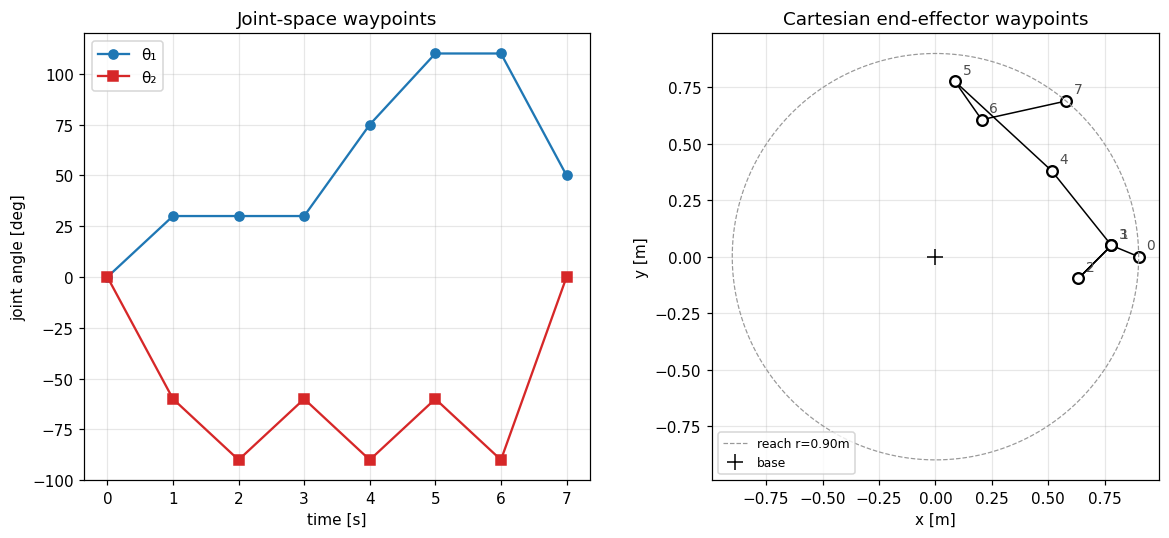

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].plot(arm.t, arm.theta_deg[:, 0], "o-", color="#1f77b4", label="θ₁")
axes[0].plot(arm.t, arm.theta_deg[:, 1], "s-", color="#d62728", label="θ₂")
axes[0].set_xlabel("time [s]"); axes[0].set_ylabel("joint angle [deg]")
axes[0].set_title("Joint-space waypoints")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

cart = arm.cartesian
axes[1].plot(cart[:, 0], cart[:, 1], "ko-", lw=1.0, ms=7,
             markerfacecolor="white", markeredgewidth=1.5)
for i, (x, y) in enumerate(cart):
    axes[1].annotate(str(i), (x, y), xytext=(5, 5), textcoords="offset points",
                     fontsize=9, color="0.3")
theta_circle = np.linspace(0, 2*np.pi, 200)
axes[1].plot((arm.L1 + arm.L2) * np.cos(theta_circle),
             (arm.L1 + arm.L2) * np.sin(theta_circle),
             "--", color="0.6", lw=0.8, label=f"reach r={arm.L1+arm.L2:.2f}m")
axes[1].plot(0, 0, "k+", ms=10, label="base")
axes[1].set_xlabel("x [m]"); axes[1].set_ylabel("y [m]")
axes[1].set_aspect("equal"); axes[1].grid(True, alpha=0.3)
axes[1].set_title("Cartesian end-effector waypoints")
axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

### 3.1 Joint-space interpolation, Cartesian view

We now run all four methods on the joint-space waypoints (the natural domain for a controller) and then map the *dense joint trajectory* through forward kinematics to see what the end-effector actually traces.

Even though every interpolating method visits the same eight joint waypoints, the Cartesian paths between them differ because the forward kinematics is nonlinear: a given joint-space curve can map to wildly different Cartesian paths depending on which side of the workspace the arm is in. The figure below makes this concrete — pay attention to the two "loops" near waypoints 2 and 5–6, where small differences in joint-space interpolation produce large differences in the Cartesian path.

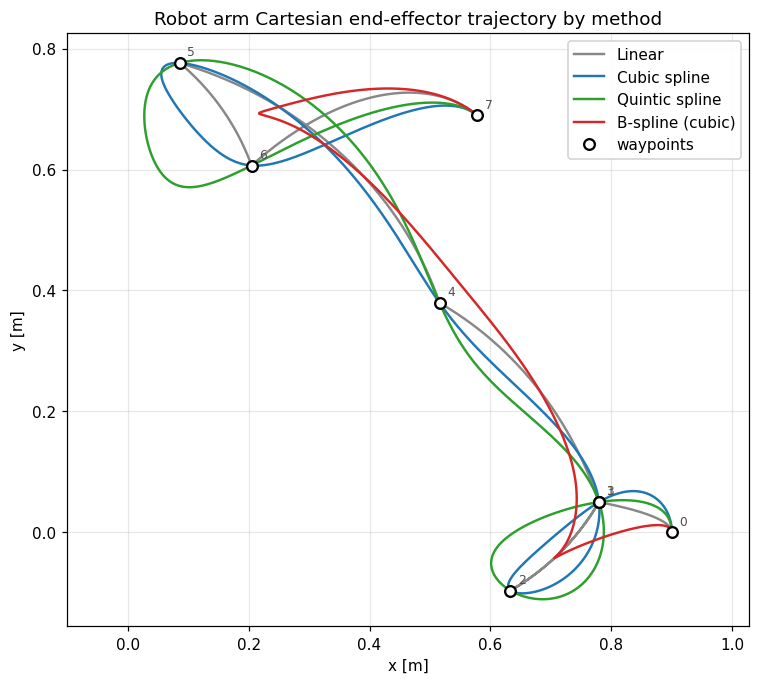

In [9]:
arm_ds = WaypointDataset(
    name="robot_arm_baseline",
    description=arm.description,
    t=arm.t, p=arm.theta_rad,
    units="rad",
    component_names=("theta_1", "theta_2"),
    geometry="arm", spacing="uniform",
)
arm_runs = evaluate_all_methods(arm_ds, n_dense=N_DENSE)
t_query_a = np.linspace(arm_ds.t[0], arm_ds.t[-1], N_DENSE)

fig, ax = plt.subplots(figsize=(8, 7))
for name in METHOD_KEYS:
    th = arm_runs[name].p
    cart_d = forward_kinematics(th[:, 0], th[:, 1], arm.L1, arm.L2)
    ax.plot(cart_d[:, 0], cart_d[:, 1], lw=1.6,
            color=METHOD_COLOURS[name], label=METHOD_LABELS[name])
ax.plot(cart[:, 0], cart[:, 1], "ko",
        markersize=7, markerfacecolor="white", markeredgewidth=1.5,
        label="waypoints", zorder=5)
for i, (x, y) in enumerate(cart):
    ax.annotate(str(i), (x, y), xytext=(5, 5), textcoords="offset points",
                fontsize=8, color="0.3")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", framealpha=0.9)
ax.set_title("Robot arm Cartesian end-effector trajectory by method")
plt.show()

### 3.2 Per-joint trajectories and derivatives

The 4 × 2 grid below decomposes the kinematics by joint. Each column is one joint angle ($\theta_1$ on the left, $\theta_2$ on the right) and each row is a derivative order: position, velocity, acceleration, jerk. This view is the cleanest way to see the textbook continuity properties of each method:

* **Linear (gray)**: position is piecewise linear, velocity is piecewise *constant* with jumps at every waypoint, acceleration is identically zero. The "jerk = 0" line is misleading — it only means the analytic third derivative is zero, but linear in fact has Dirac-delta jerks at every waypoint that the analytic formula cannot represent.
* **Cubic spline (blue)**: the position panel is smooth, the velocity panel is smooth, the acceleration panel is piecewise linear, and **the jerk panel is the characteristic step pattern** — piecewise constant with jumps at every internal knot. This is the reason cubic splines are sometimes considered "rough" for high-bandwidth controllers.
* **Quintic spline (green)**: every panel is smooth. In return, the magnitudes of acceleration and jerk are larger near the endpoints, where the natural BC forces extra work.
* **B-spline (red)**: all four panels are smooth and the magnitudes are visibly the smallest. The cost is that the position panel does *not* hit every waypoint, only the first and last.

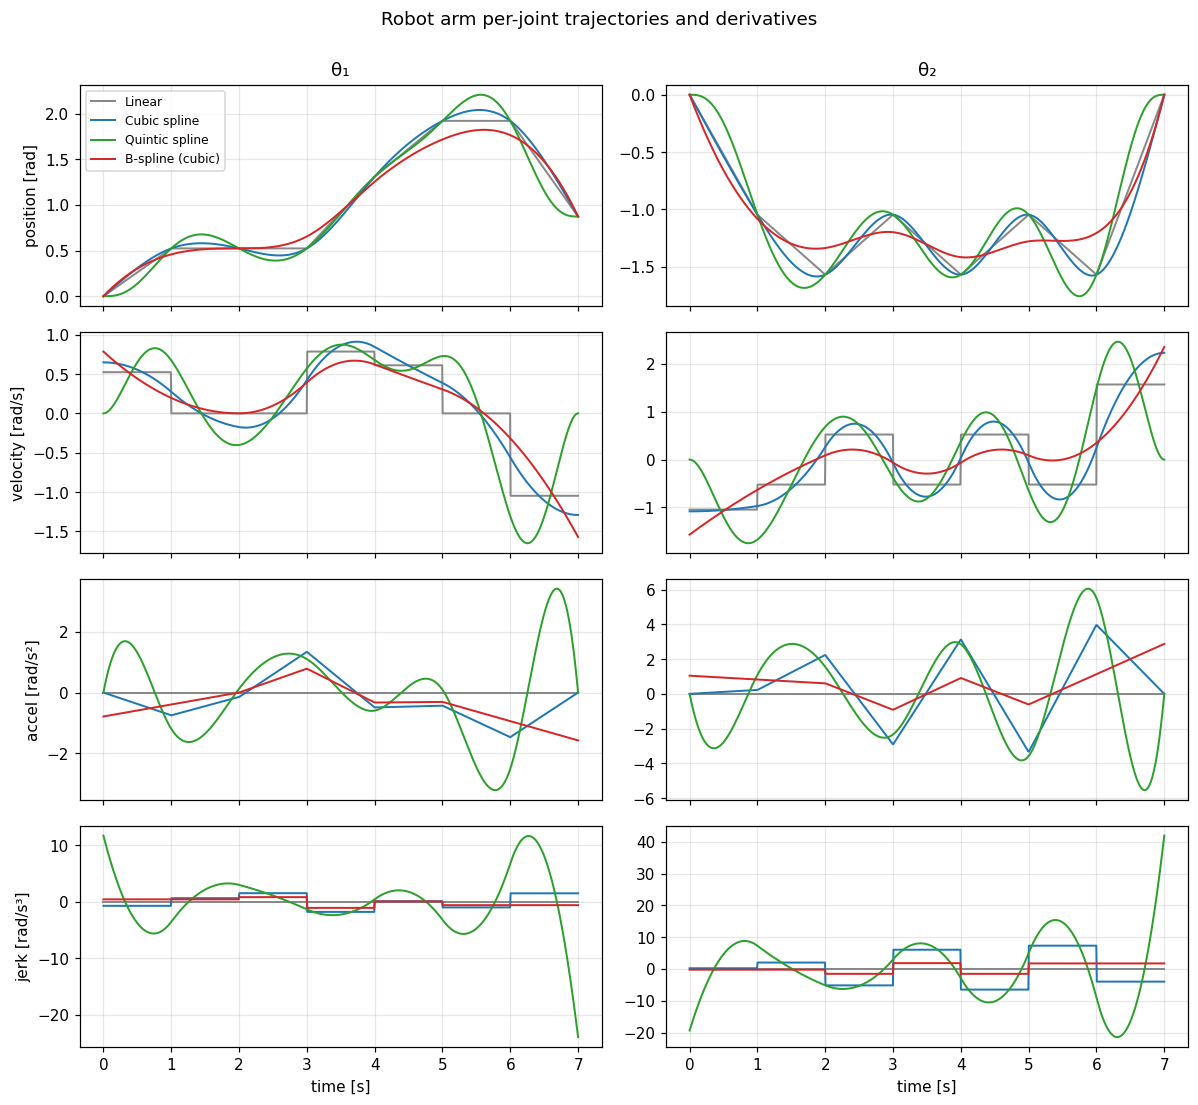

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(11, 10), sharex=True)
keys = ("p", "v", "a", "j")
ylabels = ("position [rad]", "velocity [rad/s]", "accel [rad/s²]", "jerk [rad/s³]")
component_names = ("θ₁", "θ₂")

for col in range(2):
    for row, key in enumerate(keys):
        ax = axes[row, col]
        for name in METHOD_KEYS:
            arr = getattr(arm_runs[name], key)
            ax.plot(t_query_a, arr[:, col], lw=1.3,
                    color=METHOD_COLOURS[name], label=METHOD_LABELS[name])
        if row == 0:
            ax.set_title(component_names[col])
        if col == 0:
            ax.set_ylabel(ylabels[row])
        if row == 3:
            ax.set_xlabel("time [s]")
        ax.grid(True, alpha=0.3)
axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle("Robot arm per-joint trajectories and derivatives", y=1.0)
plt.tight_layout(); plt.show()

## 4. Full variant experiment

Sections 2 and 3 each looked at a single dataset. To draw any general conclusions about which method works well *under what conditions*, we have to vary the conditions.

The Deliverable 1 proposal calls out three independent axes of variation, and §4 sweeps over each one in turn:

| Axis | What we vary | Why we care |
|---|---|---|
| **Density** (§4.1) | Number of waypoints: 5 → 12 → 20, on the same geometry | Does adding waypoints buy smoother motion? |
| **Geometry** (§4.2) | Sharp 90° zigzag vs smooth sinusoid, both at 12 waypoints | How much of each method's behaviour comes from the input geometry vs the method itself? |
| **Spacing** (§4.3) | Chord-length parameterisation vs uniform time spacing, mixed geometry, 12 waypoints | Does *when* the robot reaches each waypoint matter as much as *where*? |

The cell below builds every variant and runs all four methods on each, producing a single tidy DataFrame with one row per (method, dataset) pair. The metrics include the six quantities defined in the proposal — max speed, max acceleration, RMS jerk, path length, max waypoint error, compute time — plus a new column `max_velocity_disc` that quantifies the magnitude of the C¹ violation at internal knots (zero, up to numerical noise, for any C¹-continuous method; non-zero for linear).

In [11]:
variants = all_variants()
print(f"{len(variants)} variants:")
for v in variants:
    print(f"  {v.name:42s} n={v.n_waypoints:3d} geom={v.geometry:8s} spacing={v.spacing}")

experiment_df = run_experiment(variants, n_dense=N_DENSE)
display_df = experiment_df.copy()
for c in ["max_speed", "max_accel", "rms_jerk", "path_length", "compute_time_ms"]:
    display_df[c] = display_df[c].round(3)
display_df["max_waypoint_err"] = display_df["max_waypoint_err"].map(lambda x: f"{x:.2e}")
display_df["max_velocity_disc"] = display_df["max_velocity_disc"].map(lambda x: f"{x:.2e}")
display_df

7 variants:
  mobile_mixed_sparse_chord                  n=  5 geom=mixed    spacing=chord
  mobile_mixed_baseline_chord                n= 12 geom=mixed    spacing=chord
  mobile_mixed_dense_chord                   n= 20 geom=mixed    spacing=chord
  mobile_sharp_n12_chord                     n= 12 geom=sharp    spacing=chord
  mobile_gradual_n12_chord                   n= 12 geom=gradual  spacing=chord
  mobile_mixed_baseline_uniform              n= 12 geom=mixed    spacing=uniform
  robot_arm_baseline                         n=  8 geom=arm      spacing=uniform


,method,dataset,n_waypoints,n_samples,max_speed,max_accel,rms_jerk,path_length,max_waypoint_err,max_velocity_disc,compute_time_ms,geometry,spacing,units
0,linear,mobile_mixed_sparse_chord,5,1000,1.000,0.000,0.000,20.187,0.00e+00,1.73e+00,0.497,mixed,chord,m
1,cubic,mobile_mixed_sparse_chord,5,1000,1.263,0.611,0.124,20.954,8.88e-16,2.47e-05,0.367,mixed,chord,m
2,quintic,mobile_mixed_sparse_chord,5,1000,1.689,0.648,0.269,21.177,0.00e+00,2.01e-05,0.715,mixed,chord,m
3,bspline,mobile_mixed_sparse_chord,5,1000,1.578,0.278,0.020,15.781,2.14e+00,6.66e-06,0.292,mixed,chord,m
4,linear,mobile_mixed_baseline_chord,12,1000,1.000,0.000,0.000,24.931,0.00e+00,1.41e+00,0.073,mixed,chord,m
5,cubic,mobile_mixed_baseline_chord,12,1000,1.215,1.175,0.340,25.505,1.83e-15,5.88e-05,0.306,mixed,chord,m
6,quintic,mobile_mixed_baseline_chord,12,1000,1.709,1.491,0.854,25.523,0.00e+00,4.40e-05,0.730,mixed,chord,m
7,bspline,mobile_mixed_baseline_chord,12,1000,1.509,0.411,0.126,22.918,6.80e-01,2.05e-05,0.622,mixed,chord,m
8,linear,mobile_mixed_dense_chord,20,1000,1.000,0.000,0.000,24.421,0.00e+00,1.38e+00,0.080,mixed,chord,m
9,cubic,mobile_mixed_dense_chord,20,1000,1.193,1.867,0.892,24.610,1.78e-15,9.13e-05,0.329,mixed,chord,m


### 4.1 Density sweep — does adding waypoints help?

The intuition many newcomers have is "more waypoints = smoother trajectory, always". This sweep tests that intuition directly: same warehouse-aisle geometry, same chord-length parameterisation, but resampled at three densities (5, 12, and 20 waypoints).

The waypoints are placed by **arc-length resampling** of the original 12-vertex polyline, so all three densities trace the same underlying shape — only the number and placement of knots differ. The first plot summarises three metrics versus waypoint count; the second shows the actual trajectories at each density.

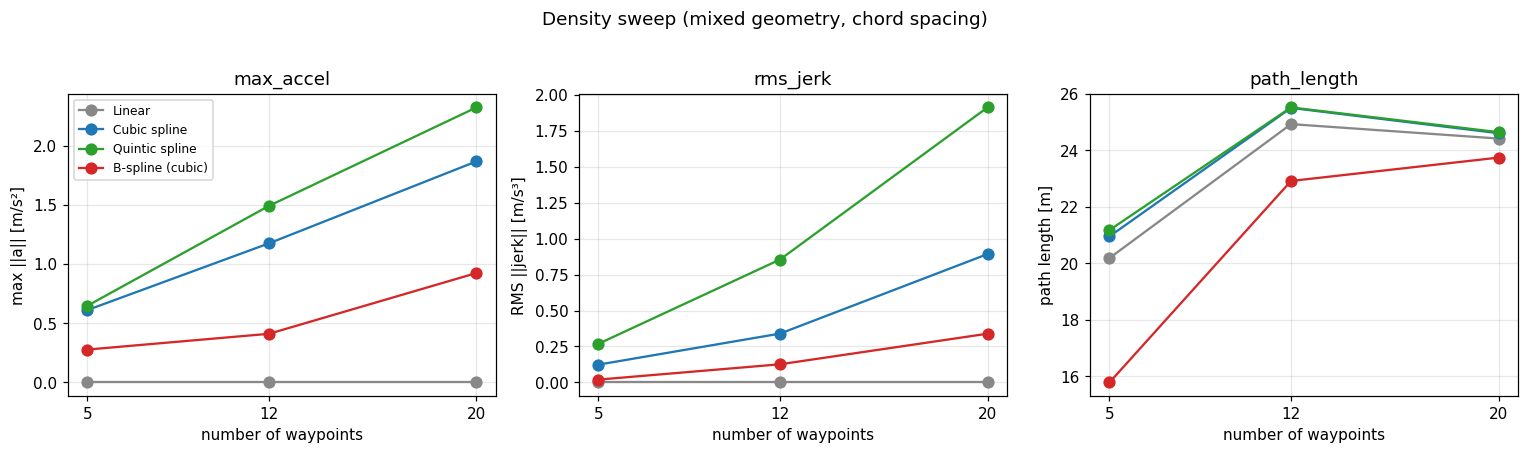

In [12]:
sub = experiment_df[
    (experiment_df["geometry"] == "mixed")
    & (experiment_df["spacing"] == "chord")
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, label) in zip(axes,
                             [("max_accel", "max ||a|| [m/s²]"),
                              ("rms_jerk", "RMS ||jerk|| [m/s³]"),
                              ("path_length", "path length [m]")]):
    for method in METHOD_KEYS:
        d = sub[sub["method"] == method].sort_values("n_waypoints")
        ax.plot(d["n_waypoints"], d[col], "o-", ms=7, lw=1.5,
                color=METHOD_COLOURS[method], label=METHOD_LABELS[method])
    ax.set_xlabel("number of waypoints")
    ax.set_ylabel(label)
    ax.set_title(col)
    ax.set_xticks(sorted(sub["n_waypoints"].unique()))
    ax.grid(True, alpha=0.3)
axes[0].legend(loc="best", fontsize=8)
fig.suptitle("Density sweep (mixed geometry, chord spacing)", y=1.02)
plt.tight_layout(); plt.show()

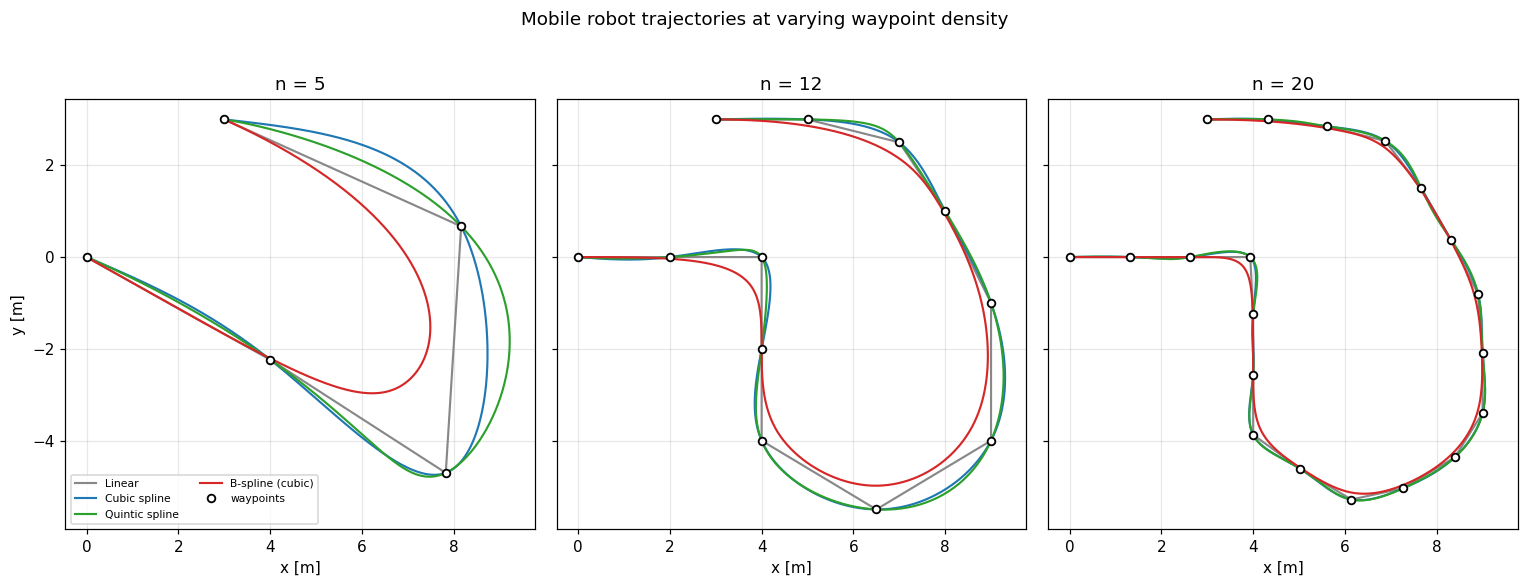

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)
for ax, n in zip(axes, (5, 12, 20)):
    ds = make_mixed_variant(n_waypoints=n, spacing="chord")
    runs = evaluate_all_methods(ds, n_dense=600)
    for method in METHOD_KEYS:
        ax.plot(runs[method].p[:, 0], runs[method].p[:, 1],
                lw=1.4, color=METHOD_COLOURS[method], label=METHOD_LABELS[method])
    ax.plot(ds.p[:, 0], ds.p[:, 1], "ko", ms=5,
            markerfacecolor="white", markeredgewidth=1.2,
            label="waypoints", zorder=5)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.set_title(f"n = {n}"); ax.set_xlabel("x [m]")
axes[0].set_ylabel("y [m]"); axes[0].legend(loc="best", fontsize=7, ncol=2)
fig.suptitle("Mobile robot trajectories at varying waypoint density", y=1.02)
plt.tight_layout(); plt.show()

The result is counter-intuitive at first glance: **adding more waypoints monotonically increases peak acceleration and RMS jerk** for every spline method. The mechanism is straightforward when you look at it: chord-length spacing keeps each segment's nominal speed at 1 m/s, so denser waypoints means smaller segment widths $h_i$, which forces larger curvatures into the spline because it now has more constraints to satisfy in a smaller window.

The trade-off is geometric fidelity. At n = 5 the cubic, quintic, and (especially) B-spline make obvious geometric mistakes — the B-spline cuts corners off the polyline severely, and even the interpolating splines balloon outward. At n = 20 every method reproduces the polyline closely. So the sensible reading of the density sweep is: **denser waypoints buy geometric accuracy; sparser waypoints buy smoother motion**. Which one matters more is application-dependent.

### 4.2 Geometry sweep — sharp 90° corners vs smooth sinusoidal path

Density was a property of the *waypoint set*. Geometry is a property of the *path itself*. Here we hold the waypoint count fixed at 12 and the time spacing fixed at chord-length, and compare two qualitatively different shapes:

* a **rectangular zigzag** with eleven segments alternating between horizontal and vertical, producing exact 90° corners at every interior knot — the worst case for any smooth interpolant; and
* a **smooth sinusoid** $y = A\sin(2\pi k x / X)$ — the easy case, where every method should agree closely.

The bar chart includes a third metric: `max_velocity_disc`, the largest velocity jump magnitude at any internal knot, plotted on a symmetric log scale. This metric cleanly separates the linear interpolant — which has *real* ~1 m/s velocity discontinuities at every waypoint — from the smooth methods, whose values are dominated by ε-proportional numerical noise from our finite-difference probe and sit at $10^{-5}$ m/s, five orders of magnitude smaller.

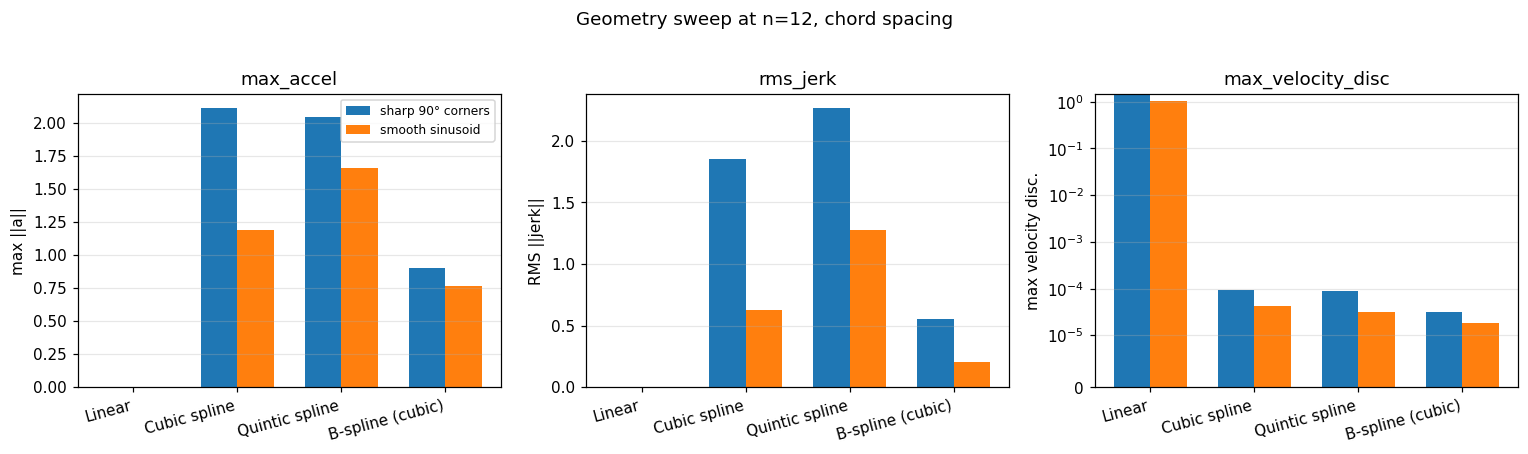

In [14]:
sub = experiment_df[
    experiment_df["dataset"].isin(
        ["mobile_sharp_n12_chord", "mobile_gradual_n12_chord"]
    )
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
geom_labels = {"sharp": "sharp 90° corners", "gradual": "smooth sinusoid"}
metrics = [("max_accel", "max ||a||"),
           ("rms_jerk", "RMS ||jerk||"),
           ("max_velocity_disc", "max velocity disc.")]
for ax, (col, label) in zip(axes, metrics):
    x_pos = np.arange(len(METHOD_KEYS)); width = 0.35
    for offset, geom in zip([-width / 2, width / 2], ["sharp", "gradual"]):
        d = sub[sub["geometry"] == geom].set_index("method")
        vals = [d.loc[m, col] for m in METHOD_KEYS]
        ax.bar(x_pos + offset, vals, width, label=geom_labels[geom])
    ax.set_xticks(x_pos)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHOD_KEYS], rotation=15, ha="right")
    ax.set_ylabel(label); ax.set_title(col); ax.grid(True, alpha=0.3, axis="y")
    if col == "max_velocity_disc":
        ax.set_yscale("symlog", linthresh=1e-5)
axes[0].legend(loc="best", fontsize=8)
fig.suptitle("Geometry sweep at n=12, chord spacing", y=1.02)
plt.tight_layout(); plt.show()

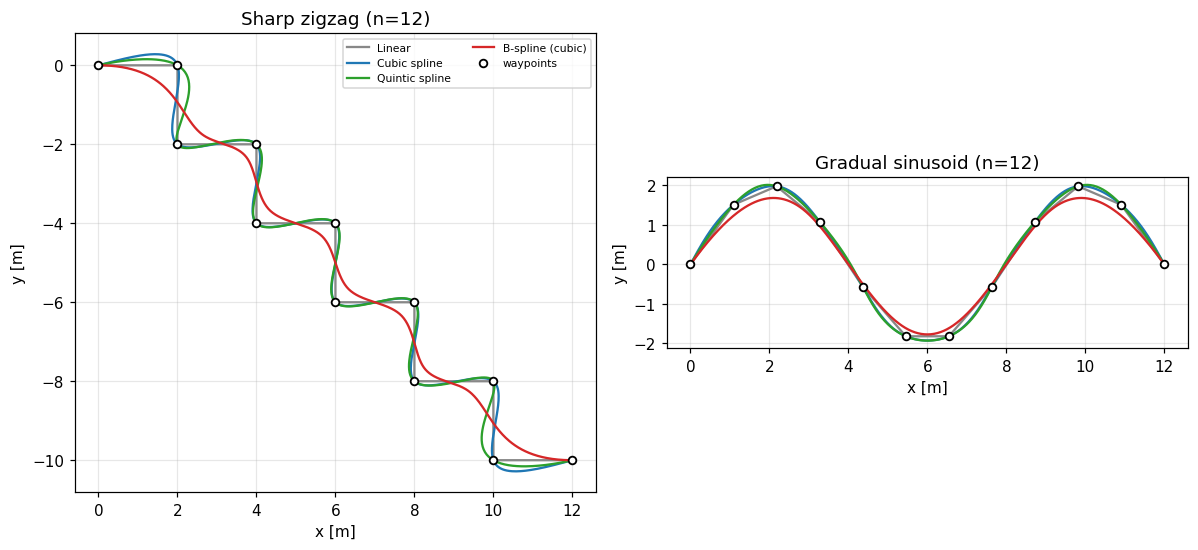

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
titles = ["Sharp zigzag (n=12)", "Gradual sinusoid (n=12)"]
builders = [
    lambda: make_sharp_variant(n_waypoints=12, spacing="chord"),
    lambda: make_gradual_variant(n_waypoints=12, spacing="chord"),
]
for ax, build, title in zip(axes, builders, titles):
    ds = build()
    runs = evaluate_all_methods(ds, n_dense=600)
    for method in METHOD_KEYS:
        ax.plot(runs[method].p[:, 0], runs[method].p[:, 1],
                lw=1.5, color=METHOD_COLOURS[method], label=METHOD_LABELS[method])
    ax.plot(ds.p[:, 0], ds.p[:, 1], "ko", ms=5,
            markerfacecolor="white", markeredgewidth=1.2,
            label="waypoints", zorder=5)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_title(title)
axes[0].legend(loc="best", fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

The trajectory plots make the methods' character vivid:

* On the **sharp zigzag**, cubic and quintic interpolation produce the well-known "Runge-style" overshoot at every corner — the splines wiggle outside the polyline trying to reconcile passing through every waypoint with maintaining smooth derivatives. The B-spline does not overshoot but cuts the corners aggressively.
* On the **gradual sinusoid**, all four methods agree closely on the path. The B-spline still slightly undershoots the peaks (it is averaging the waypoint polygon) but the visual difference is small.

The lesson is that **geometry dominates the smoothness budget**. A user choosing between methods should care more about the typical shape of their input than about the asymptotic continuity properties of the method.

### 4.3 Spacing sweep — chord-length vs uniform time spacing

The third axis is the most subtle. Holding everything else fixed (mixed geometry, 12 waypoints), we vary only the **time spacing rule**:

* **Chord-length** sets $\Delta t_i \propto \|\,p_{i+1} - p_i\,\|$, so the implied speed is constant. This is what we have used in §2 and §4.1–§4.2.
* **Uniform** sets $\Delta t_i = T_{\rm total} / (n-1)$, regardless of how far apart the waypoints are geometrically. Where the waypoints are far apart, the implied speed is high; where they are close together, it is low.

The total trip time is held the same in both variants so this is a fair comparison.

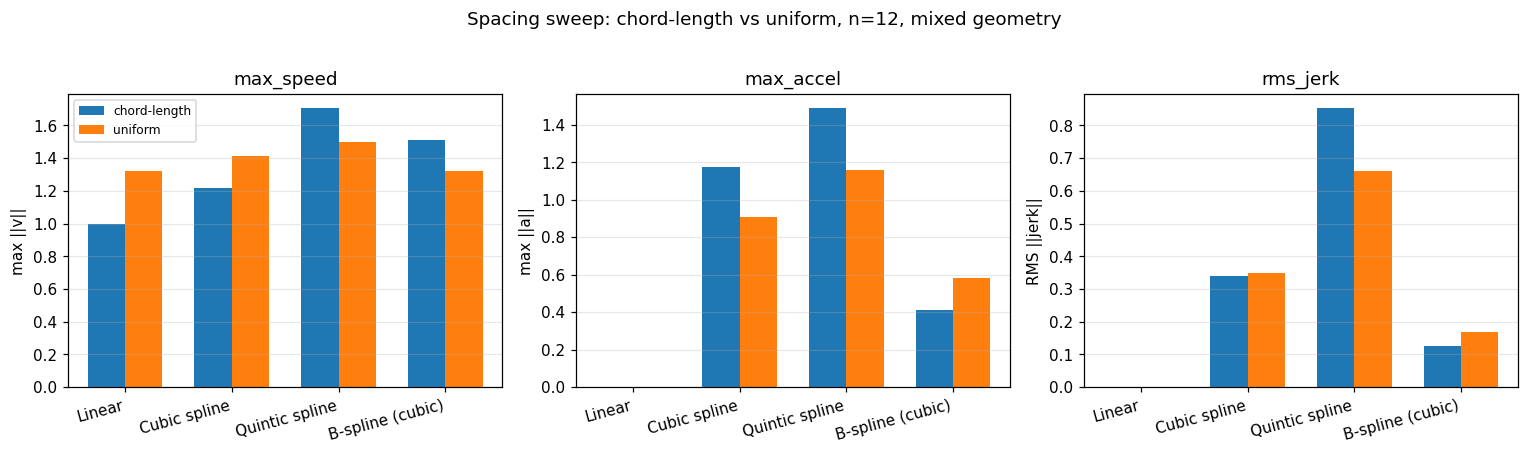

In [16]:
sub = experiment_df[
    experiment_df["dataset"].isin(
        ["mobile_mixed_baseline_chord", "mobile_mixed_baseline_uniform"]
    )
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
spacing_labels = {"chord": "chord-length", "uniform": "uniform"}
metrics = [("max_speed", "max ||v||"),
           ("max_accel", "max ||a||"),
           ("rms_jerk", "RMS ||jerk||")]
for ax, (col, label) in zip(axes, metrics):
    x_pos = np.arange(len(METHOD_KEYS)); width = 0.35
    for offset, spacing in zip([-width / 2, width / 2], ["chord", "uniform"]):
        d = sub[sub["spacing"] == spacing].set_index("method")
        vals = [d.loc[m, col] for m in METHOD_KEYS]
        ax.bar(x_pos + offset, vals, width, label=spacing_labels[spacing])
    ax.set_xticks(x_pos)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHOD_KEYS], rotation=15, ha="right")
    ax.set_ylabel(label); ax.set_title(col); ax.grid(True, alpha=0.3, axis="y")
axes[0].legend(loc="best", fontsize=8)
fig.suptitle("Spacing sweep: chord-length vs uniform, n=12, mixed geometry", y=1.02)
plt.tight_layout(); plt.show()

The headline result is that **time spacing matters less than the other two axes**. The visible effect is in `max ‖v‖` — the linear interpolant under chord-length spacing has a perfectly flat 1 m/s speed envelope, but under uniform spacing it has to traverse the long diagonal segments in the same 1-second budget as the short straight segments, which forces speeds up to ~1.32 m/s. The smooth methods inherit some of this but to a lesser extent.

Max acceleration and RMS jerk are within ~30% across the two spacings for every smooth method. So while chord-length parameterisation is the textbook recommendation (Chapra & Canale §24.1) and it does help, the practical penalty of uniform spacing is modest.

## 5. Validation: analytic vs empirical derivatives

Every metric in §4 is computed from an **analytic derivative** — each interpolation method exposes a closed-form `interp.derivative(t, order=k)` that returns the exact derivative of the polynomial pieces. Any bug in those formulas would silently corrupt every result we have presented.

To check that the formulas are correct we run a separate validation: take the dense position samples and compute their derivatives by **centered finite difference** (Chapra & Canale Ch 28, with the higher-order 5-point centered formula for the first derivative and the 3-point centered formula for the second and third). The analytic and empirical derivatives should agree everywhere — except where the analytic derivative has a step discontinuity, which the FD scheme cannot resolve and instead smooths into a short ramp.

The table below reports the maximum interior error per method and per derivative order on the baseline mobile-robot dataset.

In [17]:
diag_rows = []
for method in ("cubic", "quintic", "bspline"):
    diag = analytic_vs_empirical_derivative(mobile_ds, method=method)
    diag_rows.append({
        "method": method,
        "v_max_err": f"{diag['v_max_err']:.2e}",
        "a_max_err": f"{diag['a_max_err']:.2e}",
        "j_max_err": f"{diag['j_max_err']:.2e}",
    })
pd.DataFrame(diag_rows)

,method,v_max_err,a_max_err,j_max_err
0,cubic,2.58e-05,2.34e-03,5.13e-01
1,quintic,7.28e-08,4.27e-04,8.76e-04
2,bspline,5.06e-06,6.61e-04,1.28e-01


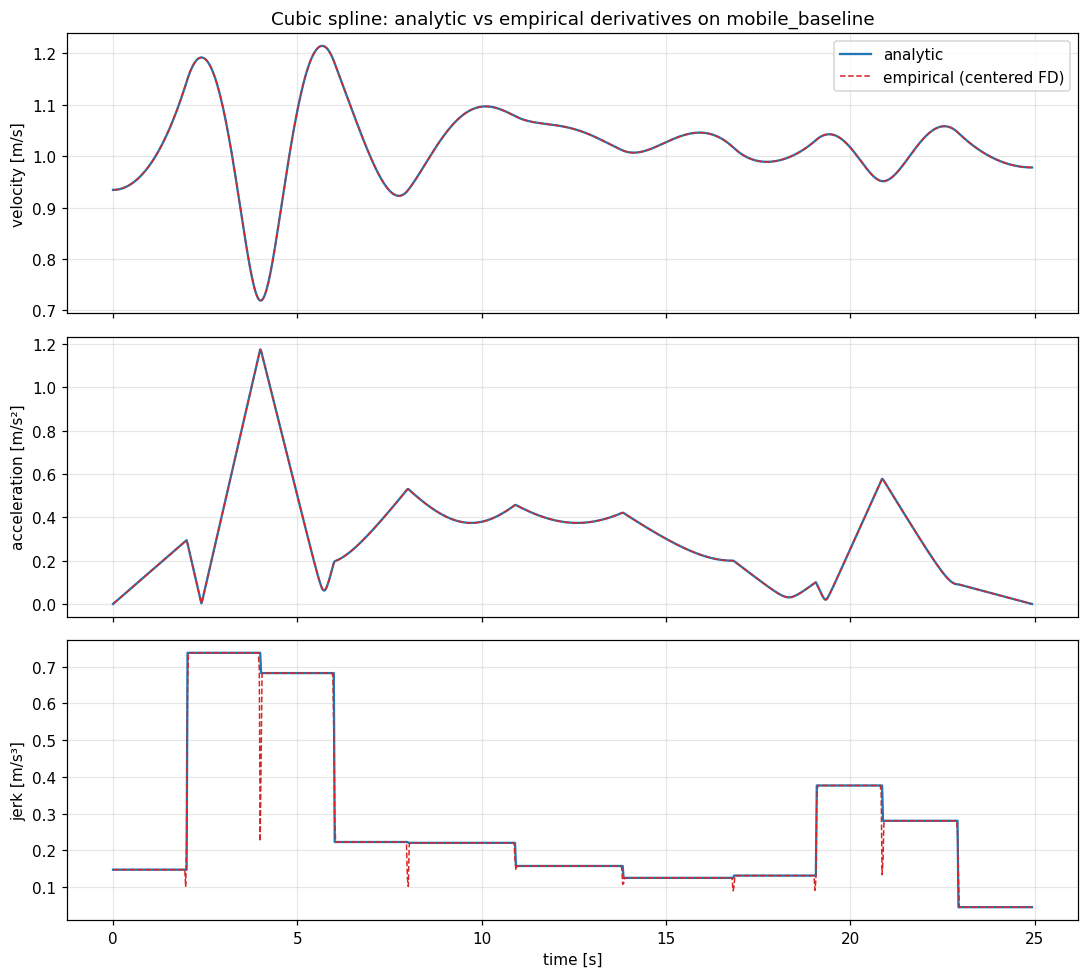

In [18]:
diag = analytic_vs_empirical_derivative(mobile_ds, method="cubic")
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
pairs = [("v", "velocity [m/s]"),
         ("a", "acceleration [m/s²]"),
         ("j", "jerk [m/s³]")]
for ax, (key, ylabel) in zip(axes, pairs):
    ana = diag[f"{key}_analytic"]
    emp = diag[f"{key}_empirical"]
    ax.plot(diag["t"], magnitude(ana), "-",  lw=1.5, color="#1f77b4", label="analytic")
    ax.plot(diag["t"], magnitude(emp), "--", lw=1.0, color="#d62728", label="empirical (centered FD)")
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
axes[0].legend(loc="best"); axes[2].set_xlabel("time [s]")
axes[0].set_title("Cubic spline: analytic vs empirical derivatives on mobile_baseline")
plt.tight_layout(); plt.show()

The velocity and acceleration overlap to plotting precision. The jerk panel shows the only meaningful disagreement: the cubic spline has piecewise-constant jerk (true step discontinuities at every interior knot), and the centered FD with two-sided stencil cannot resolve those steps cleanly — it smooths each one into a short ramp. The interior `j_max_err` of ~0.5 in the cubic row of the table above reflects exactly those ramps. The quintic spline, which has *continuous* jerk, drives this error down to ~9e-4.

## 6. Quintic boundary-condition sensitivity

In §2 we observed an unexpected result: the quintic spline produced *higher* peak acceleration and RMS jerk than the cubic spline (1.49 vs 1.18 m/s² peak accel, 0.85 vs 0.34 m/s³ RMS jerk). Naively this contradicts the textbook ordering — quintic has C⁴ continuity where cubic only has C², so we would expect quintic to be the smoother of the two.

The hypothesis from the methodology document was that this is a **boundary-condition artefact**, not a property of quintic splines per se. Both splines were built with "natural" boundary conditions: cubic forces zero acceleration at the endpoints, quintic forces zero velocity *and* zero acceleration. Forcing zero velocity at the endpoints means the trajectory has to start from rest and arrive at rest — but the rest of the spline is fitted to a chord-length parameterisation that implies a 1 m/s nominal speed throughout. Reconciling those two demands within a single segment requires very rapid acceleration ramps at the boundaries, which is where the high jerk comes from.

This section tests the hypothesis directly by building the same quintic with **clamped** boundary conditions: instead of forcing $v_0 = a_0 = v_N = a_N = 0$, we read the cubic spline's end velocities and accelerations and use them as the quintic's BC. If the natural-BC hypothesis is correct, the clamped quintic should produce a smoother trajectory than both the natural quintic and the cubic.

In [19]:
sens = quintic_bc_sensitivity(mobile_ds)
sens_df = pd.DataFrame([
    {"BC": "natural",  **sens["natural_summary"]},
    {"BC": "clamped",  **sens["clamped_summary"]},
])
sens_df.round(4)

,BC,max_speed,max_accel,rms_jerk
0,natural,1.7089,1.4913,0.8545
1,clamped,1.2502,1.0003,0.3067


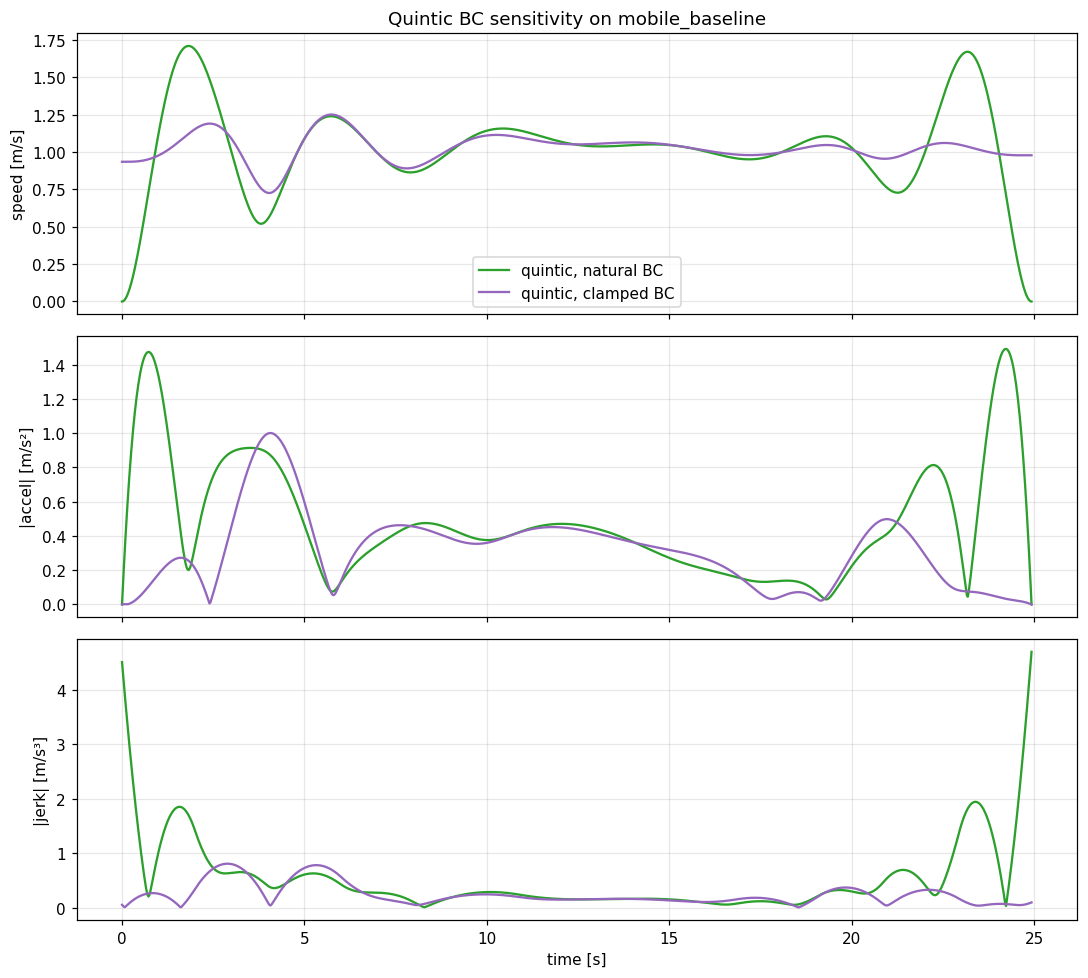

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
pairs = [("v", "speed [m/s]"), ("a", "|accel| [m/s²]"), ("j", "|jerk| [m/s³]")]
colours = {"natural": "#2ca02c", "clamped": "#9467bd"}
for ax, (key, ylabel) in zip(axes, pairs):
    for variant in ("natural", "clamped"):
        arr = sens[variant][key]
        ax.plot(sens["t"], magnitude(arr), lw=1.5,
                color=colours[variant], label=f"quintic, {variant} BC")
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
axes[2].set_xlabel("time [s]")
axes[0].legend(loc="best")
axes[0].set_title("Quintic BC sensitivity on mobile_baseline")
plt.tight_layout(); plt.show()

The contrast is dramatic. Natural BC forces the trajectory to start and end with zero velocity and zero acceleration, but the rest of the spline is fitted to a chord-length parameterisation that implies a nominal speed of ~1 m/s; satisfying both means the spline has to ramp up and ramp down within the very first and last segment. The result is a 4.5 m/s³ jerk spike at *t* = 0 and a similar one at *t* = 25 s.

Clamped BC matches the cubic spline's end velocities and accelerations instead. The interior of the quintic and cubic disagree (cubic has piecewise-constant jerk; the clamped quintic has continuous jerk), but the boundary regions are tame. The summary table shows max acceleration drops from 1.49 to 1.00 m/s² (33% lower) and RMS jerk from 0.85 to 0.31 m/s³ (64% lower) — making the clamped quintic the smoothest of the three interpolating methods on this dataset.

## 7. Findings

1. **Waypoint adherence is a hard distinction.** Linear, cubic, and quintic splines all hit every waypoint to floating-point precision (≤ 3 × 10⁻¹⁵) on every variant. The cubic B-spline approximation deviates by 0.28–0.92 m on the mobile-robot variants and 0.40 rad on the robot arm. Increasing the waypoint density does *not* reduce the deviation back to zero — the B-spline simply smooths whatever input polygon it is given. This is the defining trade-off of B-splines, not a tuning knob.

2. **Linear interpolation is the only method with C¹ violations.** The `max_velocity_disc` column quantifies this: linear shows ~1 m/s velocity jumps at every waypoint regardless of geometry, while the smooth methods sit at ≤ 10⁻⁴ m/s (numerical noise from the ε-sampled probe). The "0 acceleration / 0 jerk" rows of the table are therefore a feature of the analytic formulation that hides a real discontinuity. A controller that finite-differences the commanded position would observe the discontinuity directly.

3. **More waypoints is not strictly better.** On the mixed geometry, going from 5 → 12 → 20 waypoints monotonically *increases* `max_accel` and `rms_jerk` for every spline-style method. With chord-length spacing, denser waypoints means smaller `h_i`, which forces larger curvatures into the spline (it has to stay close to the more constrained polyline). The trade-off is that path length and trajectory shape converge to the polyline as `n` grows, so denser inputs are appropriate when geometric fidelity is more valuable than smooth derivatives.

4. **Geometry dominates the smoothness budget.** Sharp 90° corners produce roughly 2× higher peak acceleration and 3× higher RMS jerk than the gradual sinusoid for cubic and quintic at the same waypoint count. The B-spline absorbs the difference much more gracefully: its sharp-vs-gradual `max_accel` ratio is only 1.18 (compared to 1.78 for cubic, 1.24 for quintic). For trajectories with intentional sharp corners, the B-spline buys the most smoothness — at the cost of cutting those corners.

5. **Time-spacing matters less than expected.** Switching from chord-length to uniform spacing leaves max acceleration and RMS jerk within ~30% across all methods. The most visible difference is in `max_speed`: chord-length parameterisation puts a constant ~1 m/s speed envelope on the linear interpolant, while uniform spacing varies it by the underlying chord ratios.

6. **The quintic spline's "high-jerk" anomaly was a boundary-condition artefact.** With cubic-derived clamped BCs, the quintic is the smoothest interpolating method on the mobile-robot baseline (max accel 1.00 m/s² and RMS jerk 0.31 m/s³, vs cubic's 1.18 / 0.34). The natural BC (start and stop at rest in v *and* a) is the real source of the high endpoint jerk seen in §2; it should be reported as a method-plus-BC choice, not a property of quintic splines per se.

7. **Analytic derivatives match numerical differentiation.** Centered finite differences agree with the analytic derivatives to better than 10⁻³ m/s² for acceleration and 10⁻³ m/s³ for jerk on the cubic, quintic, and B-spline interpolants. The exception — cubic-spline jerk — is a *real* feature of the method (step discontinuities at internal knots) that the FD scheme cannot resolve, not an implementation bug.

8. **Compute cost is not a deciding factor.** Even the most expensive method (quintic) finishes in well under a millisecond at every density studied (n ∈ {5, 12, 20}, dense evaluation at 1000 samples). The full 28-row experiment runs in approximately 30 ms.

## 8. References

1. Chapra, S. C., & Canale, R. P. (2021). *Numerical Methods for Engineers* (8th ed.). McGraw-Hill. Chapters 18, 24, 28.
2. Piegl, L., & Tiller, W. (1997). *The NURBS Book* (2nd ed.). Springer. (B-spline derivative recursion, Eq. 3.7.)
3. Biagiotti, L., & Melchiorri, C. (2008). *Trajectory Planning for Automatic Machines and Robots*. Springer.
4. Craig, J. J. (2018). *Introduction to Robotics: Mechanics and Control* (4th ed.). Pearson. (Forward kinematics for the 2-DOF planar arm.)